In [ ]:
import pandas as pd

df = pd.read_csv("data/housing_data.csv")

df.head()

In [ ]:
import pandas as pd

df = pd.read_csv("data/housing_data.csv")

df.head()

In [ ]:
B

In [ ]:
import sys
print(sys.executable)

In [ ]:
import pandas as pd

print(pd.__version__)

In [2]:
import pandas as pd

df = pd.read_csv("housing_data.csv")

df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,Age
0,250000,3,2,1800,10
1,320000,4,3,2200,5
2,180000,2,1,1200,20
3,450000,5,4,3000,3
4,275000,3,2,1900,8


In [3]:
# Check dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Price       5 non-null      int64
 1   Bedrooms    5 non-null      int64
 2   Bathrooms   5 non-null      int64
 3   SquareFeet  5 non-null      int64
 4   Age         5 non-null      int64
dtypes: int64(5)
memory usage: 332.0 bytes


In [4]:
# Summary statistics
df.describe()

,Price,Bedrooms,Bathrooms,SquareFeet,Age
count,5.000000,5.000000,5.000000,5.000000,5.000000
mean,295000.000000,3.400000,2.400000,2020.000000,9.200000
std,100374.299499,1.140175,1.140175,657.267069,6.610598
min,180000.000000,2.000000,1.000000,1200.000000,3.000000
25%,250000.000000,3.000000,2.000000,1800.000000,5.000000
50%,275000.000000,3.000000,2.000000,1900.000000,8.000000
75%,320000.000000,4.000000,3.000000,2200.000000,10.000000
max,450000.000000,5.000000,4.000000,3000.000000,20.000000


In [5]:
# Check for missing values
df.isnull().sum()

Price         0
Bedrooms      0
Bathrooms     0
SquareFeet    0
Age           0
dtype: int64

In [6]:
# Show column names
print(df.columns)

Index(['Price', 'Bedrooms', 'Bathrooms', 'SquareFeet', 'Age'], dtype='str')


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
X = df[['Bedrooms', 'Bathrooms', 'SquareFeet', 'Age']]
y = df['Price']

print(X.head())
print(y.head())

   Bedrooms  Bathrooms  SquareFeet  Age
0         3          2        1800   10
1         4          3        2200    5
2         2          1        1200   20
3         5          4        3000    3
4         3          2        1900    8
0    250000
1    320000
2    180000
3    450000
4    275000
Name: Price, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 4
Testing rows: 1


In [10]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [11]:
predictions = model.predict(X_test)

print(predictions)

[274615.38461538]


In [12]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 45384.61538461596
MSE: 2059763313.6095195
R2: nan


c:\Users\mclus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [13]:
print("X_train:", len(X_train))
print("X_test:", len(X_test))
print("y_train:", len(y_train))
print("y_test:", len(y_test))

X_train: 4
X_test: 1
y_train: 4
y_test: 1


In [14]:
df

,Price,Bedrooms,Bathrooms,SquareFeet,Age
0,250000,3,2,1800,10
1,320000,4,3,2200,5
2,180000,2,1,1200,20
3,450000,5,4,3000,3
4,275000,3,2,1900,8


Matplotlib is building the font cache; this may take a moment.


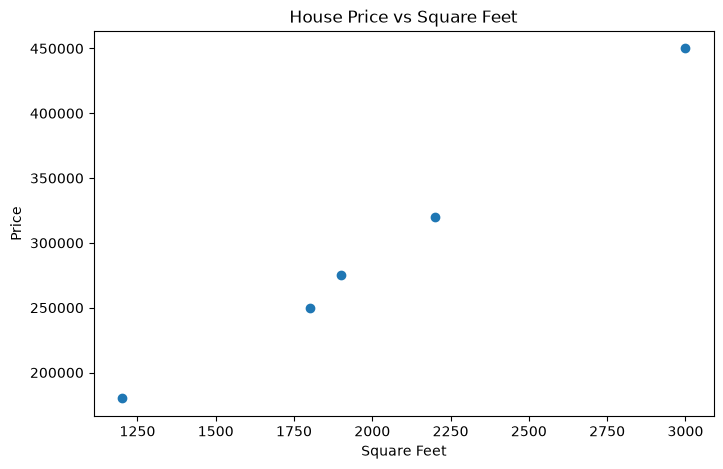

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df["SquareFeet"], df["Price"])
plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.title("House Price vs Square Feet")
plt.show()

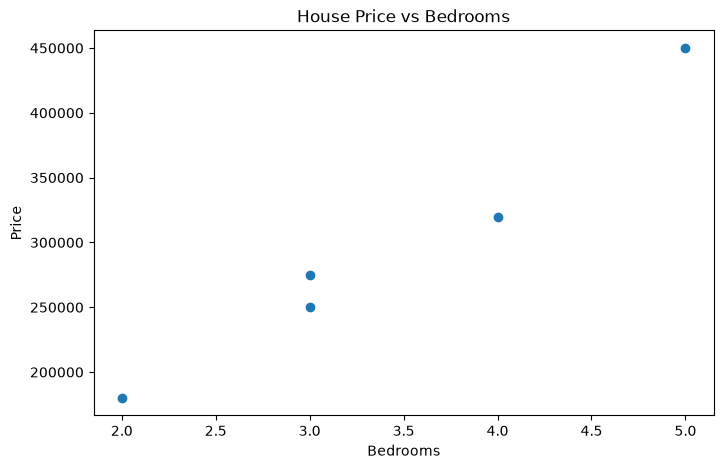

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(df["Bedrooms"], df["Price"])
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.title("House Price vs Bedrooms")
plt.show()

In [17]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": predictions
})

results

,Actual Price,Predicted Price
1,320000,274615.384615


In [18]:
sample_house = [[4, 3, 2200, 5]]

predicted_price = model.predict(sample_house)

print(f"Predicted House Price: ${predicted_price[0]:,.2f}")

Predicted House Price: $274,615.38


c:\Users\mclus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [20]:
import numpy as np

np.random.seed(42)

houses = []

for i in range(100):
    bedrooms = np.random.randint(2, 6)
    bathrooms = np.random.randint(1, 5)
    sqft = np.random.randint(1000, 4000)
    age = np.random.randint(1, 30)

    price = (
        sqft * 150
        + bedrooms * 10000
        + bathrooms * 5000
        - age * 1000
        + np.random.randint(-15000, 15000)
    )

    houses.append(
        [price, bedrooms, bathrooms, sqft, age]
    )

new_df = pd.DataFrame(
    houses,
    columns=[
        "Price",
        "Bedrooms",
        "Bathrooms",
        "SquareFeet",
        "Age"
    ]
)

new_df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,Age
0,338802,4,4,1860,15
1,426550,5,1,2638,26
2,416320,4,3,2482,24
3,203269,5,4,1130,22
4,636261,5,4,3853,2


In [21]:
print(len(new_df))

100


In [22]:
new_df.shape

(100, 5)

In [ ]:
for i in range(100):

In [ ]:
for i in range(1000):

In [25]:
import numpy as np
import pandas as pd

houses = []

for i in range(1000):
    bedrooms = np.random.randint(2, 6)
    bathrooms = np.random.randint(1, 5)
    sqft = np.random.randint(1000, 4000)
    age = np.random.randint(1, 30)

    price = (
        sqft * 150
        + bedrooms * 10000
        + bathrooms * 5000
        - age * 1000
        + np.random.randint(-15000, 15000)
    )

    houses.append(
        [price, bedrooms, bathrooms, sqft, age]
    )

new_df = pd.DataFrame(
    houses,
    columns=[
        "Price",
        "Bedrooms",
        "Bathrooms",
        "SquareFeet",
        "Age"
    ]
)

print(new_df.shape)
new_df.head()

(1000, 5)


,Price,Bedrooms,Bathrooms,SquareFeet,Age
0,323508,5,2,1833,23
1,259777,3,3,1574,29
2,512577,3,2,3352,20
3,333041,3,3,2077,11
4,507725,2,1,3311,21


In [26]:
new_df.to_csv("housing_data_1000.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [27]:
import os

print(os.listdir())

['house_price_prediction.ipynb', 'housing_data.csv', 'housing_data_1000.csv', 'notebook']


In [28]:
df = pd.read_csv("housing_data_1000.csv")

print(df.shape)
df.head()

(1000, 5)


,Price,Bedrooms,Bathrooms,SquareFeet,Age
0,323508,5,2,1833,23
1,259777,3,3,1574,29
2,512577,3,2,3352,20
3,333041,3,3,2077,11
4,507725,2,1,3311,21


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = new_df[['Bedrooms', 'Bathrooms', 'SquareFeet', 'Age']]
y = new_df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("R2:", round(r2, 4))

MAE: 8286.77
MSE: 87447003.97
R2: 0.9951


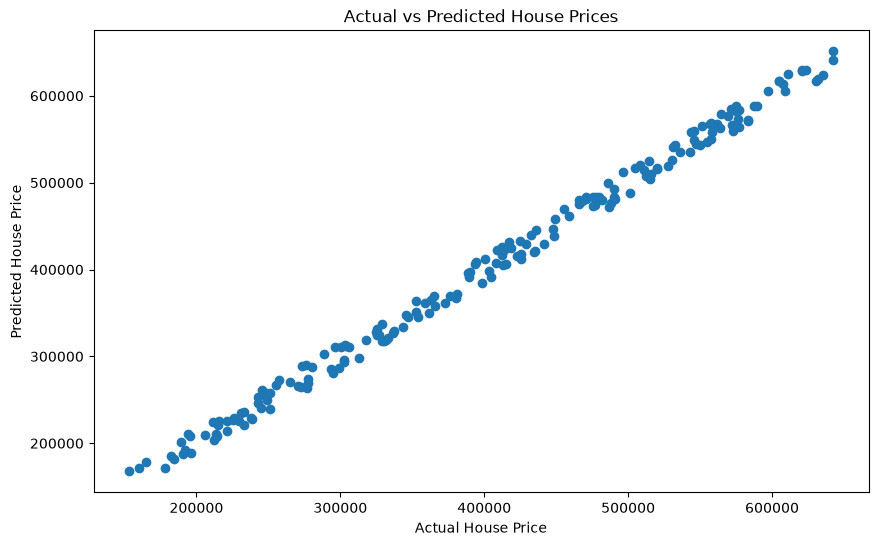

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.savefig(
    "notebook/images/actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

In [33]:
import os

print(os.listdir("notebook/images"))

['.gitkeep', 'actual_vs_predicted.png']
